# Débruitage d'images avec un autoencodeur convolutif

Ce notebook présente la conception, l'entraînement et l'évaluation d'un modèle d'autoencodeur pour le débruitage d'images.

L'objectif est de permettre à un réseau de neurones convolutif d'apprendre à supprimer le bruit ajouté à des images, afin de retrouver une version plus fidèle à l'originale.

In [2]:
import os # For file and directory operations
import numpy as np # For numerical operations
import pandas as pd # For data manipulation
import matplotlib.pyplot as plt # For plotting
from imageio import imread # For reading images
from skimage.transform import resize # For resizing images
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim # For image quality metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # For confusion matrix visualization
from sklearn.model_selection import train_test_split # For splitting dataset
import tensorflow as tf # For building and training the model
from PIL import Image # For image processing
from tensorflow.keras import layers, models # For building neural network layers and models
from tensorflow.keras.callbacks import EarlyStopping # For early stopping during training
import seaborn as sns # For advanced plotting

# Configuration parameters
DATASET_DIR = "./Dataset"
IMAGE_SIZE = (256, 256)
NOISE_FACTOR = 0.2
BATCH_SIZE = 16
EPOCHS = 150

## Chargement du jeu de données

Les images sont chargées à partir d’un dossier local, redimensionnées à une taille fixe, puis converties en valeurs flottantes normalisées entre 0 et 1.

In [6]:
def load_images_from_folder(folder, target_size=(128, 128)):
    """
    Load and resize images from a specified folder.
    Args:
        folder (str): Path to the folder containing images.
        target_size (tuple): Desired size to resize images to.
    Returns:
        np.ndarray: Array of resized images.
    """
    images = []
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        if os.path.isfile(path):
            try:
                img = imread(path)
                img = resize(img, target_size, anti_aliasing=True)
                if img.ndim == 2:
                    img = np.stack((img,) * 3, axis=-1)
                images.append(img)
            except Exception:
                continue
    return np.array(images, dtype=np.float32)

print("Chargement du dataset...")
images = load_images_from_folder(DATASET_DIR, IMAGE_SIZE)
print(f"{len(images)} images chargées.")

images = np.clip(images, 0., 1.)

Chargement du dataset...


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_16368\4225866843.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imread(path)


980 images chargées.


## Ajout de bruit aux images

Afin d'entraîner le modèle à retirer du bruit, on ajoute un bruit gaussien artificiel aux images d'origine.
Ce bruit est contrôlé par un facteur de bruit (`NOISE_FACTOR`).

In [7]:
def add_noise(imgs, noise_factor=0.2):
    """
    Add random noise to images.
    Args:
        imgs (np.ndarray): Array of images.
        noise_factor (float): Factor to scale the noise.
    Returns:
        np.ndarray: Noisy images.
    """
    noisy = imgs + noise_factor * np.random.randn(*imgs.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

noisy_images = add_noise(images, NOISE_FACTOR)

## Séparation du jeu de données

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    noisy_images, images, test_size=0.2, random_state=42 # Split dataset into training and testing sets
)

## Construction du modèle d’autoencodeur

L’autoencodeur est composé de deux parties principales :
- **Encodeur** : réduit la taille de l’image et extrait les caractéristiques essentielles.
- **Décodeur** : reconstruit l’image à partir de ces caractéristiques.

In [5]:
def build_autoencoder(input_shape):
    """
    Build a convolutional autoencoder model.
    Args:
        input_shape (tuple): Shape of the input images.
    Returns:
        tf.keras.Model: Compiled autoencoder model.
    """
    inputs = layers.Input(shape=input_shape)
    c1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2,2), padding='same')(c1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2,2), padding='same')(c2)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    u1 = layers.UpSampling2D((2,2))(c3)
    concat1 = layers.Concatenate()([u1, c2])
    c4 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(concat1)
    u2 = layers.UpSampling2D((2,2))(c4)
    concat2 = layers.Concatenate()([u2, c1])
    c5 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(concat2)
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(c5)
    return models.Model(inputs, outputs)

autoencoder = build_autoencoder((*IMAGE_SIZE, 3))
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │        867 │ conv2d_4[0][0]    │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 232,451 (908.01 KB)

 Trainable params: 232,451 (908.01 KB)

 Non-trainable params: 0 (0.00 B)

## Métriques et fonction de perte

Pour évaluer les performances du modèle, on utilise deux mesures principales : le PSNR et le SSIM.

- Le **PSNR (Peak Signal-to-Noise Ratio)** permet de mesurer la différence globale entre l’image originale et l’image reconstruite. En résumé, il indique à quel point le modèle a réussi à réduire le bruit sans dégrader l’image. Plus la valeur du PSNR est élevée, meilleure est la qualité du débruitage.

    \> 35 dB → Très bon résultat : la reconstruction est presque identique à l’image originale, les différences sont à peine perceptibles visuellement.

    Entre 30 et 35 dB → Bon résultat : légère dégradation visible, mais l’image reste de bonne qualité.

    Entre 20 et 30 dB → Qualité moyenne : le débruitage est correct mais on perçoit des pertes de détails.

    < 20 dB → Mauvais résultat : le bruit ou les artefacts sont clairement visibles, la reconstruction est de faible qualité.

- Le **SSIM (Structural Similarity Index)** mesure la similarité entre deux images en prenant en compte la structure, la luminosité et le contraste. Contrairement au PSNR, il se rapproche davantage de la perception humaine de la qualité visuelle. Une valeur proche de 1 signifie que l’image débruitée est très proche de l’originale.

    \> 0.95 → Excellente similarité : très peu de différences structurelles, rendu quasi identique à l’image d’origine.

    Entre 0.90 et 0.95 → Bonne similarité : quelques différences légères, mais globalement très fidèle.

    Entre 0.70 et 0.90 → Résultat moyen : le modèle conserve la structure générale, mais certaines zones sont altérées.

    < 0.70 → Mauvaise similarité : la structure de l’image est déformée, perte visible de détails et de cohérence visuelle.

Ces deux indicateurs sont complémentaires : le PSNR donne une mesure globale d’erreur, tandis que le SSIM permet d’évaluer la cohérence visuelle. Ensemble, ils offrent une vision plus complète de la qualité du débruitage obtenu par l’autoencodeur.


La fonction de perte combinée associe une **MSE (Mean Squared Error)** et une pénalité liée à la dissimilarité structurelle.

In [6]:
def psnr_metric(y_true, y_pred):
    """
    Calculate Peak Signal-to-Noise Ratio (PSNR) between true and predicted images.
    Args:
        y_true (tf.Tensor): Ground truth images.
        y_pred (tf.Tensor): Predicted images.
    Returns:
        tf.Tensor: PSNR value.
    """
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    """
    Calculate Structural Similarity Index (SSIM) between true and predicted images.
    Args:
        y_true (tf.Tensor): Ground truth images.
        y_pred (tf.Tensor): Predicted images.
    Returns:
        tf.Tensor: SSIM value.
    """
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

def combined_loss(y_true, y_pred):
    """
    Combined loss function using Mean Squared Error (MSE) and Structural Similarity Index (SSIM).
    Args:
        y_true (tf.Tensor): Ground truth images.
        y_pred (tf.Tensor): Predicted images.
    Returns:
        tf.Tensor: Combined loss value.
    """
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.8 * mse + 0.2 * ssim_loss

autoencoder.compile( # Compile the autoencoder model
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[psnr_metric, ssim_metric]
)

## Entraînement du modèle

In [ ]:
callbacks = [EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)] # Early stopping callback

history = autoencoder.fit( # Train the autoencoder model
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

autoencoder.save("denoising_autoencoder-150.h5") # Save the trained model
print("Model saved as 'denoising_autoencoder-150.h5'")

Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - loss: 0.0677 - psnr_metric: 23.6184 - ssim_metric: 0.6801 - val_loss: 0.0685 - val_psnr_metric: 23.6505 - val_ssim_metric: 0.6763
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - loss: 0.0668 - psnr_metric: 23.7159 - ssim_metric: 0.6843 - val_loss: 0.0676 - val_psnr_metric: 23.6846 - val_ssim_metric: 0.6805
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - loss: 0.0662 - psnr_metric: 23.5895 - ssim_metric: 0.6878 - val_loss: 0.0664 - val_psnr_metric: 23.9207 - val_ssim_metric: 0.6856
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - loss: 0.0648 - psnr_metric: 23.9377 - ssim_metric: 0.6937 - val_loss: 0.0655 - val_psnr_metric: 23.8914 - val_ssim_metric: 0.6905
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - loss: 0.0638 - psnr_metric: 24.0031 - ssim_metric: 0.6981 - val_loss: 0.0645 - val_psnr_metric: 24.0745 - val_ssim_metric: 0.6945
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - loss: 0.0628 - psnr_metric

Model saved as 'denoising_autoencoder-50.h5'


## Visualisation des courbes d’apprentissage

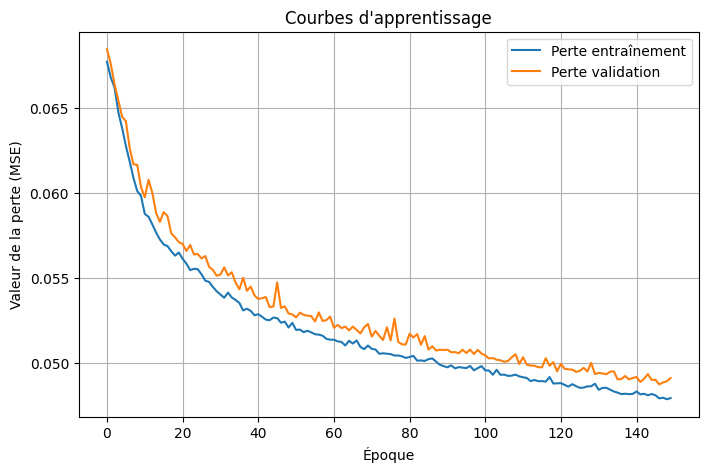

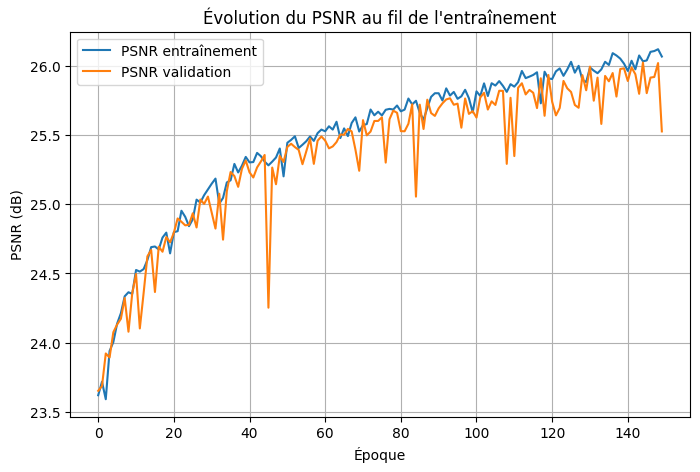

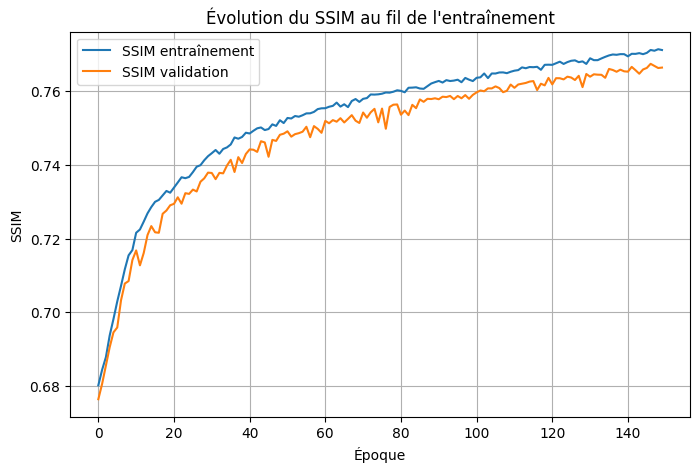

In [9]:
loss_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(loss_df["loss"], label="Perte entraînement")
plt.plot(loss_df["val_loss"], label="Perte validation")
plt.title("Courbes d'apprentissage")
plt.xlabel("Époque")
plt.ylabel("Valeur de la perte (MSE)")
plt.legend()
plt.grid(True)
plt.show()

if "psnr_metric" in loss_df.columns and "val_psnr_metric" in loss_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["psnr_metric"], label="PSNR entraînement")
    plt.plot(loss_df["val_psnr_metric"], label="PSNR validation")
    plt.title("Évolution du PSNR au fil de l'entraînement")
    plt.xlabel("Époque")
    plt.ylabel("PSNR (dB)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("PSNR metrics not found in training history.")

if "ssim_metric" in loss_df.columns and "val_ssim_metric" in loss_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["ssim_metric"], label="SSIM entraînement")
    plt.plot(loss_df["val_ssim_metric"], label="SSIM validation")
    plt.title("Évolution du SSIM au fil de l'entraînement")
    plt.xlabel("Époque")
    plt.ylabel("SSIM")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("SSIM metrics not found in training history.")
    

## Évaluation des performances du modèle

In [10]:
def summarize_performance(y_true, y_pred):
    """
    Summarize and print PSNR and SSIM performance metrics.
    Args:
        y_true (np.ndarray): Ground truth images.
        y_pred (np.ndarray): Predicted images.
    """
    psnr_scores = [psnr(y_true[i], y_pred[i], data_range=1.0) for i in range(len(y_true))]
    ssim_scores = [ssim(y_true[i], y_pred[i], channel_axis=-1, data_range=1.0) for i in range(len(y_true))]
    print("\nRésumé des performances :")
    print(f"  PSNR moyen : {np.mean(psnr_scores):.2f} dB")
    print(f"  SSIM moyen : {np.mean(ssim_scores):.4f}")

y_pred = autoencoder(x_test).numpy()
summarize_performance(y_test, y_pred)


Résumé des performances :
  PSNR moyen : 25.92 dB
  SSIM moyen : 0.7679


# Matrices de Confusion

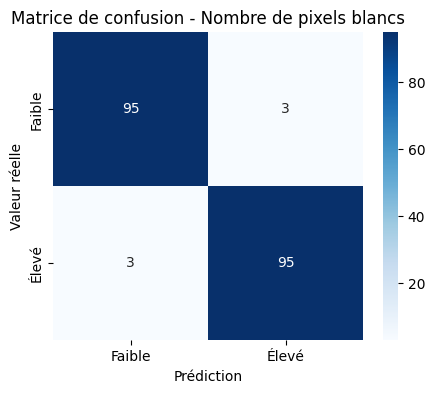

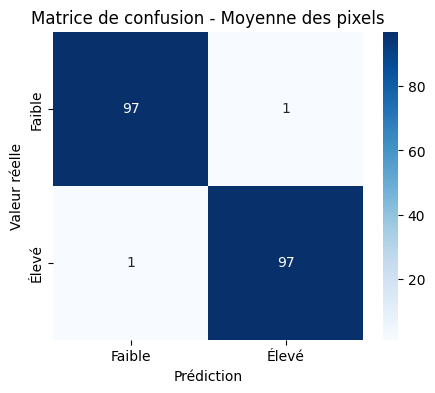

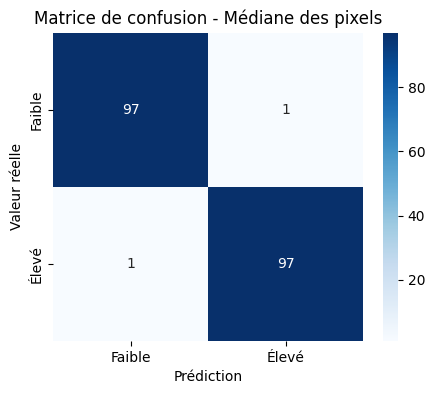

In [11]:

def plot_confusion_matrix(y_true, y_pred, title):
    """
    Plot confusion matrix for binary classification.
    Args:
        y_true (np.ndarray): True binary labels.
        y_pred (np.ndarray): Predicted binary labels.
        title (str): Title for the plot.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Faible", "Élevé"],
                yticklabels=["Faible", "Élevé"])
    plt.title(title)
    plt.xlabel("Prédiction")
    plt.ylabel("Valeur réelle")
    plt.show()

threshold = 0.5

true_pixel_counts = np.sum(y_test > 0.5, axis=(1,2,3))
pred_pixel_counts = np.sum(y_pred > 0.5, axis=(1,2,3))

y_true_bin = (true_pixel_counts > np.median(true_pixel_counts)).astype(int)
y_pred_bin = (pred_pixel_counts > np.median(pred_pixel_counts)).astype(int)

plot_confusion_matrix(y_true_bin, y_pred_bin, "Matrice de confusion - Nombre de pixels blancs")

true_means = np.mean(y_test, axis=(1,2,3))
pred_means = np.mean(y_pred, axis=(1,2,3))

y_true_bin = (true_means > np.median(true_means)).astype(int)
y_pred_bin = (pred_means > np.median(pred_means)).astype(int)

plot_confusion_matrix(y_true_bin, y_pred_bin, "Matrice de confusion - Moyenne des pixels")

true_medians = np.median(y_test, axis=(1,2,3))
pred_medians = np.median(y_pred, axis=(1,2,3))

y_true_bin = (true_medians > np.median(true_medians)).astype(int)
y_pred_bin = (pred_medians > np.median(pred_medians)).astype(int)

plot_confusion_matrix(y_true_bin, y_pred_bin, "Matrice de confusion - Médiane des pixels")


## Affichage des résultats de débruitage

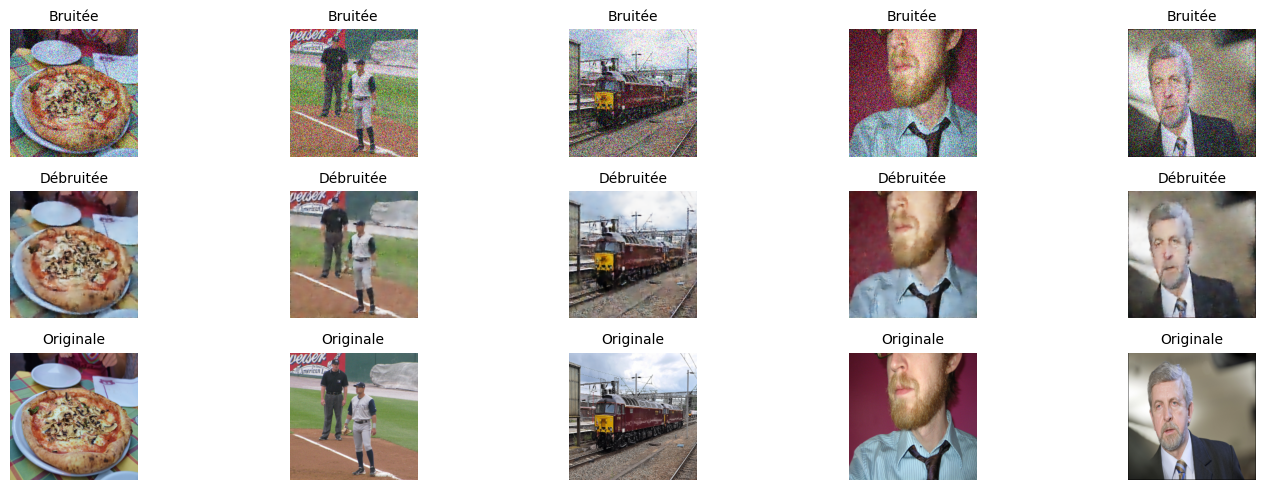

In [12]:
def display_results(model, x_test, y_test, n=5):
    """
    Display original, noisy, and denoised images.
    Args:
        model (tf.keras.Model): Trained autoencoder model.
        x_test (np.ndarray): Noisy test images.
        y_test (np.ndarray): Ground truth test images.
        n (int): Number of images to display.
    """
    indices = np.random.choice(len(x_test), n, replace=False)
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        noisy = x_test[idx]
        denoised = model(noisy[None, ...])[0].numpy()
        original = y_test[idx]
        
        for j, (im, title) in enumerate(zip([noisy, denoised, original], ["Bruitée", "Débruitée", "Originale"])):
            ax = plt.subplot(3, n, i + 1 + j*n)
            plt.imshow(im)
            plt.title(title, fontsize=10)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

display_results(autoencoder, x_test, y_test)

## Test sur images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step


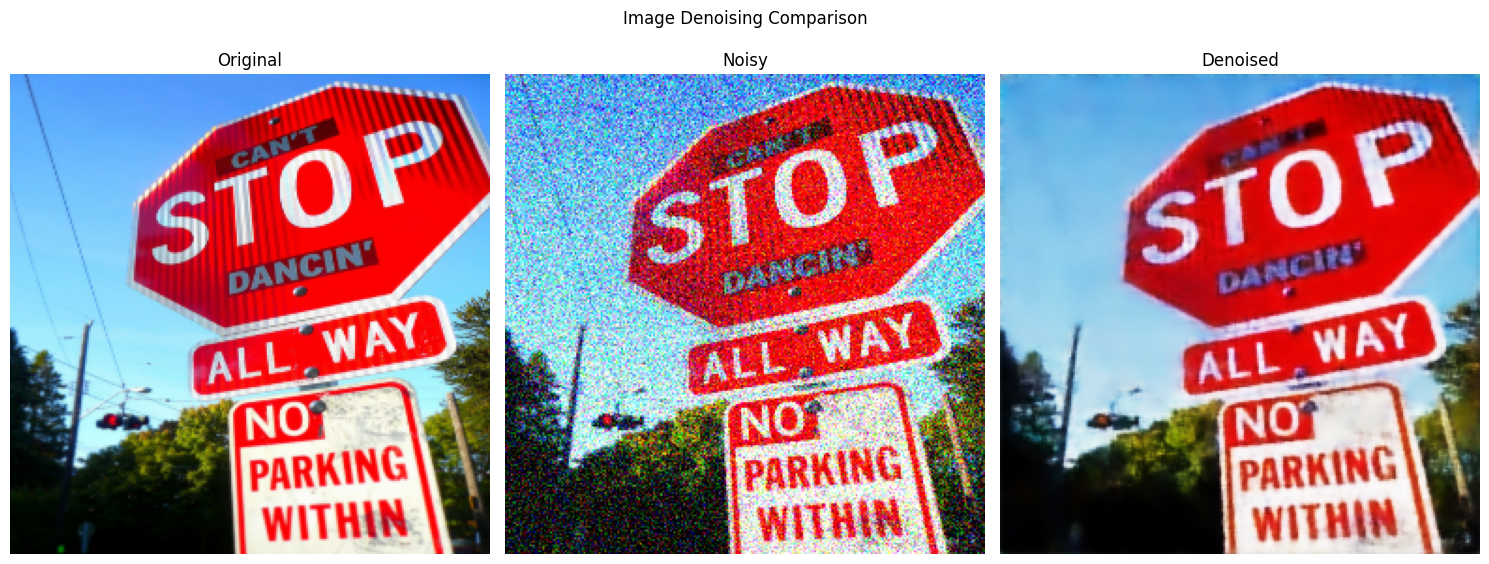

PSNR: 22.03 dB
SSIM: 0.7163


In [5]:
model = tf.keras.models.load_model("denoising_autoencoder-150.h5", compile=False)

IMAGE_SIZE = (256, 256)
NOISE_FACTOR = 0.2

image_path = "./example.jpg"

img = Image.open(image_path).convert("RGB")
img_resized = resize(np.array(img) / 255.0, IMAGE_SIZE, anti_aliasing=True)

def add_noise(imgs, noise_factor=0.2):
    """
    Add random noise to images.
    Args:
        imgs (np.ndarray): Array of images.
        noise_factor (float): Factor to scale the noise.
    Returns:
        np.ndarray: Noisy images.
    """
    noisy = imgs + noise_factor * np.random.randn(*imgs.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

noisy_img = add_noise(np.expand_dims(img_resized, 0), NOISE_FACTOR)
noisy = noisy_img[0]

denoised = model.predict(noisy_img)[0]
denoised = np.clip(denoised, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
titles = ["Original", "Noisy", "Denoised"]
images = [img_resized, noisy, denoised]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(np.clip(im, 0, 1))
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Image Denoising Comparison")
plt.tight_layout()
plt.show()

p = psnr(img_resized, denoised, data_range=1.0)
s = ssim(img_resized, denoised, channel_axis=-1, data_range=1.0)

print(f"PSNR: {p:.2f} dB")
print(f"SSIM: {s:.4f}")
